# Softmax: exercise

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/odsl-team/block-course-mar26-ml/blob/main/tutorials/ex_lecture_7b_multi_modal.ipynb)

**Goal:** In this year's iteration of the course, you're getting a unique perspective... seeing deep generative models before learning about classifiers.

So, let's try to answer a simple question... _Is it ever beneficial to cast a problem as a classification problem instead of a simple regression?_ 

And, if so, do you have a tool in your toolbox to save the regression task?

- **Lecturer:** Nicole Hartman
- **Date:** 24 Mar 2026

In [2]:
import torch
import matplotlib.pyplot as plt

**The task:** 
We want to regress a multimodal distribution:

$$x \sim \mathrm{Unif}(0,2)$$

$$k \sim \mathrm{Categorical}(\vec{p}=[\frac{1}{6},\frac{1}{2},\frac{1}{3}])$$


$$y \sim 
\begin{cases}
    \frac{1}{2}\mathcal{N}(x+1,0.1^2) , &\quad k=0 \\
    \frac{1}{2}\mathcal{N}(x,1^2), &\quad k=1 \\
    \frac{1}{3} \mathcal{N}(x-1,0.25^2) , &\quad k=2
\end{cases}
$$

Let's visualize this probability distribution for $x=0$:

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

xx = torch.linspace(-5, 5, 1001)

probs = torch.tensor([1 / 6, 1 / 2, 1 / 3])
mu = torch.tensor([-2, 0.0, 3])
sigma = torch.tensor([0.1, 1.0, 0.25])


def plot_mixture(x=0.0):
    p0 = (
        torch.distributions.Normal(loc=x + mu[0], scale=sigma[0]).log_prob(xx).exp()
    )
    p1 = (
        torch.distributions.Normal(loc=x + mu[1], scale=sigma[1]).log_prob(xx).exp()
    )
    p2 = (
        torch.distributions.Normal(loc=x + mu[2], scale=sigma[2]).log_prob(xx).exp()
    )

    p = 1 / 6 * p0 + 1 / 2 * p1 + 1 / 3 * p2

    plt.figure()
    plt.plot(xx, probs[0] * p0, label="p0")
    plt.plot(xx, probs[1] * p1, label="p1")
    plt.plot(xx, probs[2] * p2, label="p2")
    plt.plot(xx, p, label="p", color="black", linewidth=3, alpha=0.5)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("p(x)")
    plt.title(f"Mixture of 3 Gaussians (x = {x:.2f})", loc="right")
    plt.show()

interact(plot_mixture, x=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0));


interactive(children=(FloatSlider(value=0.0, description='x', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

In [4]:
def sample_y(x,N=int(1e6)):
    ''' 
    Quickly sanity check that I have the syntax right!
    '''

    k = torch.distributions.Multinomial(
        probs=probs).sample((N,)).argmax(dim=-1)
    y = torch.randn(N) * sigma[k] + (mu[k]+x)
    return y

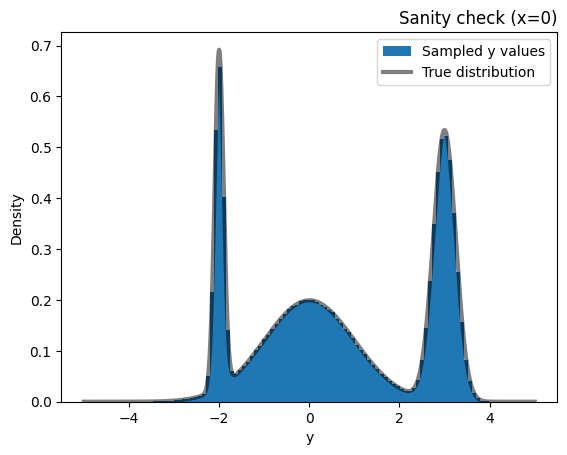

In [5]:
y = sample_y(0.)
plt.hist(y, bins=100, density=True,label="Sampled y values")

x=0.
mu_local = x + mu

p0 = torch.distributions.Normal(loc=mu_local[0], scale=sigma[0]).log_prob(xx).exp()
p1 = torch.distributions.Normal(loc=mu_local[1], scale=sigma[1]).log_prob(xx).exp()
p2 = torch.distributions.Normal(loc=mu_local[2], scale=sigma[2]).log_prob(xx).exp()

p = probs[0]*p0 + probs[1]*p1 + probs[2]*p2
plt.plot(xx, p, color="black", linewidth=3, alpha=0.5,label="True distribution")
plt.xlabel("y")
plt.ylabel("Density")
plt.title("Sanity check (x=0)",loc='right')
plt.legend()

Great! Looks good. 

Let's move on to getting the full batch.

In [6]:
def get_batch(N=512):
    """
    Inputs:
    - N: batch size
    Outputs:
    - x: (N,) tensor of input values
    - y: (N,) tensor of output values
    """

    x = torch.rand(N) * 6 - 3 # uniform (-3,3)

    k = torch.distributions.Multinomial(probs=probs).sample((N,)).argmax(dim=-1)
    y = torch.randn(N) * sigma[k] + (mu[k] + x)
    return x[:,None],y[:,None]

In [7]:
# Test it works
x,y = get_batch(int(1e3))

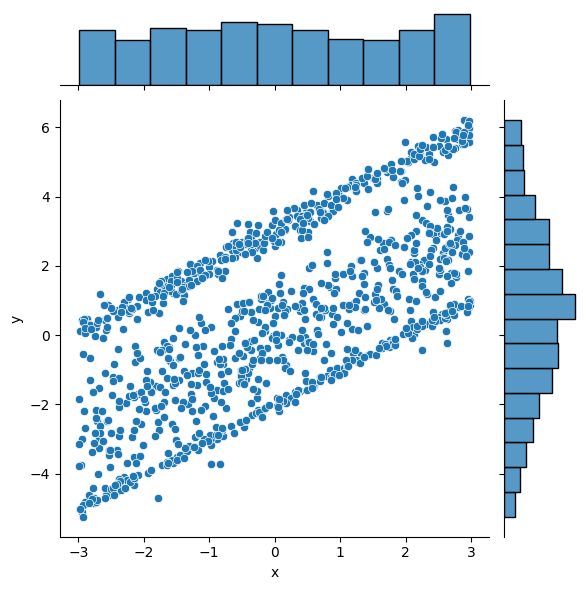

In [8]:
# Let's visualize the output in a seaborn plot
import seaborn as sns

g = sns.jointplot(x=x.squeeze(), y=y.squeeze(), kind="scatter")  
g.set_axis_labels("x", "y")

The streaks on the plot are vizualizing the three modes of the distribution!

Great, now that we have a dataset, let's fit it with 3 techniques:
1) [Regression](#regression)
2) [Classifier](#classifier) (to learn to predict which bin of a distribution we're in)
3) [Conditional flow matching model](#cfm)

## Part 1: Fit a regression model
<a id="regression"></a>

In [9]:
import torch.nn as nn
import torch.nn.functional as F

In [10]:
# ?nn.Linear

In [11]:
H = 64
m_reg = nn.Sequential(
    nn.Linear(1,H),
    nn.ReLU(),
    nn.Linear(H,H),
    nn.ReLU(),
    nn.Linear(H,1)
)

**Test your understanding:** From what Jed taught us last week, can you predict what the loss will be for a perfectly trained model?

<span style="color:green">**Soln:**</span>

We know the truth target distribution, b/c we specified the forward model.

$$ p(y|x) = \frac{1}{6} \mathcal{N}(-2+x, .1^2) + \frac{1}{2}\mathcal{N}(x, 1^2) + \frac{1}{3} \mathcal{N}(3+x, 0.25^2) $$

The probability distribution for a regression target is a **Gaussian distribution** so it will learn the mean of the target distribution, let's calculate it!

$$
\begin{align}
\mathbb{E}_x &= \mathbb {E}_x [\frac{1}{6} \mathcal{N}(-2+x, .1^2) + \frac{1}{2}\mathcal{N}(x, 1^2) + \frac{1}{3} \mathcal{N}(3+x, 0.25^2)]\\
&= \frac{1}{6} (-2+x) + \frac{1}{2}(x) + \frac{1}{3} (3+x) \\
&= \frac{2}{3} + x
\end{align}
$$

**Follow-up:** Can you predict what the loss would be for a perfectly trained model??

<span style="color:green">**Soln:** Plug in the true regression model, and get an MC estimate of the ideal loss when we're perfectly trained
</span>

In [12]:
# ?nn.MSELoss

In [13]:
x,y = get_batch(int(1e7)) # I ran w/ a few different N to get a feeling for the stat error

y_pred = x + 2/3
L_MC = nn.MSELoss()(y_pred, y)
print(L_MC)

tensor(3.7456)


**Sanity check:** Before training... do you have a loss bigger than the ideal loss??

In [14]:
x, y = get_batch(int(1e7))

with torch.no_grad():
    y_pred0 = m_reg(x)
    L0 = nn.MSELoss()(y_pred0,y)
print('init loss', L0.item())

init loss 7.7111968994140625


Great! Sanity check passed ✅

In [15]:
def train(m, training_steps=1_000, lr=1e-3, N_print=50):
    '''
    Training loop

    Inputs:
    - m: pytorch model
    - training_steps
    - lr: learning rate
    - N_print: How often to print the training loss to the screen
    Outputs:
    - m: trained model
    - losses
    '''

    # Set up the optimizer
    opt = torch.optim.Adam(m.parameters(), lr=lr)

    losses = []

    # Training loop
    for i in range(training_steps):

        x, y = get_batch()  # Draw samples
        y_pred = m(x)
        loss = nn.MSELoss()(y_pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()
        
        if i % N_print == 0:
            print(f'Iter {i:2d}, loss = {loss.item():.3f}')

        losses.append(loss.item())

    return m, losses

In [16]:
m_reg, losses = train(m_reg)

Iter  0, loss = 7.425
Iter 50, loss = 3.713
Iter 100, loss = 3.573
Iter 150, loss = 3.758
Iter 200, loss = 3.581
Iter 250, loss = 3.748
Iter 300, loss = 3.716
Iter 350, loss = 3.746
Iter 400, loss = 3.587
Iter 450, loss = 3.868
Iter 500, loss = 3.569
Iter 550, loss = 3.853
Iter 600, loss = 3.591
Iter 650, loss = 3.702
Iter 700, loss = 3.888
Iter 750, loss = 3.932
Iter 800, loss = 3.867
Iter 850, loss = 3.893
Iter 900, loss = 3.652
Iter 950, loss = 3.892


Text(0, 0.5, 'MSE Loss')

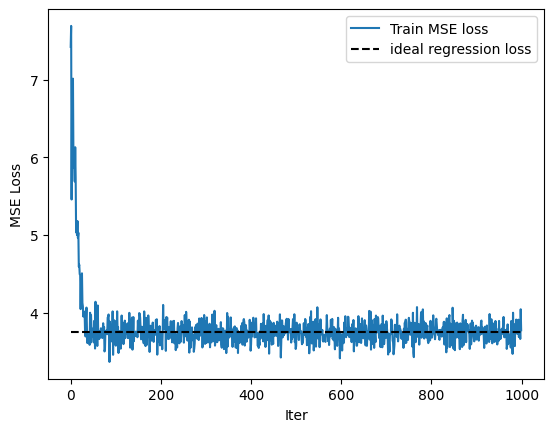

In [17]:
plt.plot(losses,label='Train MSE loss')
plt.hlines(L_MC.numpy(),0,len(losses),'k',ls='--',label='ideal regression loss')

plt.legend()
plt.xlabel('Iter')
plt.ylabel("MSE Loss")

**Q:** Can you think of a way to visulize the output of this model??

In [18]:
xx

tensor([-5.0000, -4.9900, -4.9800,  ...,  4.9800,  4.9900,  5.0000])

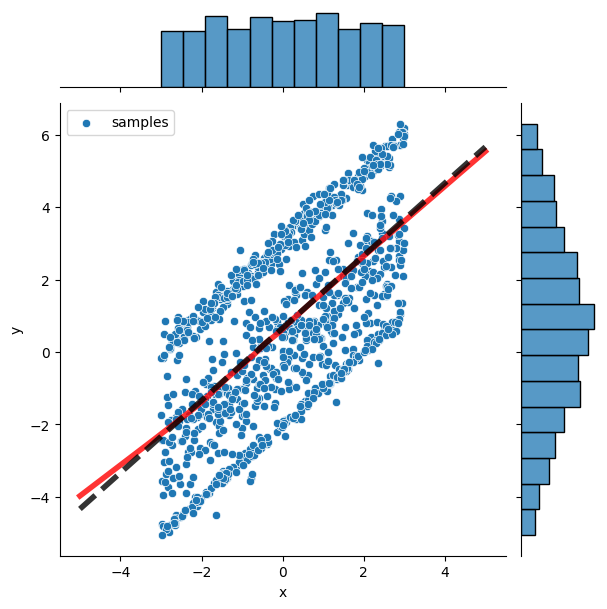

In [19]:
# Let's visualize the output in a seaborn plot
x,y = get_batch(int(1e3))

g = sns.jointplot(
    x=x.squeeze().numpy(), y=y.squeeze().numpy(), 
    kind="scatter", label='samples'
)  
g.set_axis_labels("x", "y")

with torch.no_grad():
    yy = m_reg(xx[:, None])
    plt.plot(xx.numpy(), yy.squeeze().numpy(), "r", lw=4, alpha=0.8, label='fitted model')
    plt.plot(
        xx.numpy(), xx.numpy()+2/3, "k", ls='--', lw=4, alpha=0.8, label="true (for regression)"
    )


Great! As indicated by the loss, we've converged to the true solution, alhtough you can see we accumulate error when we're extrapolating outside of the training dataset.

## Part 2: Fit a classifier model
<a id="classifier"></a>

**Motivating Q:** Can we improve on the result above if we instead cast this as a classification problem??

Let's consider 25 bins from [-5,5] and predict which bin the $y$ sample is in!

In [20]:
nbins = 25

edg = torch.linspace(-5, 5, nbins+1)
y_mid = 0.5 * (edg[1:] + edg[:-1])

In [21]:
import ipywidgets as widgets
from ipywidgets import interact


def get_prob(x, xx):
    p0 = (
        torch.distributions.Normal(loc=x + mu[0], scale=sigma[0]).log_prob(xx).exp()
    )
    p1 = (
        torch.distributions.Normal(loc=x + mu[1], scale=sigma[1]).log_prob(xx).exp()
    )
    p2 = (
        torch.distributions.Normal(loc=x + mu[2], scale=sigma[2]).log_prob(xx).exp()
    )

    p = 1 / 6 * p0 + 1 / 2 * p1 + 1 / 3 * p2
    return p

def plot_mixture_bins(x=0.0):
    p = get_prob(x, xx)
    p_coarse = get_prob(x, y_mid)

    plt.figure()

    plt.hist(y_mid,edg,weights=p_coarse, label='discretized prob')

    plt.plot(xx, p, label="p", color="black", linewidth=3, alpha=0.5)
    plt.legend()
    plt.xlabel("y")
    plt.ylabel("p(y)")
    plt.title("Mixture of 3 Gaussians & discretization", loc="right")
    plt.show()


interact(plot_mixture_bins, x=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0));


interactive(children=(FloatSlider(value=0.0, description='x', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

Write a batch sampling function that returns which bin you're in
- Hint: look at the `np.discretize` fucntion
- Plan: allow for underflow and overflow, so 100+2 = 102 classes

In [22]:
import numpy as np

In [23]:
def get_batch_class(N=512):
    """
    Get the batch for the classification task

    Input:
    - N : # samples
    Outputs:
    - x: (N,1): torch array of floats
    - y: (N,1): torch array of ints

    """

    x,y = get_batch(N)

    y_int = np.digitize(y.squeeze(), edg)

    return x,torch.tensor(y_int)

**Q: What's the xentropy training loss before training??**

**Soln:** If the classes were uniformly distributed, would be

$\rightarrow \log(\mathrm{nbins}+2)$

In [24]:
np.log(nbins+2)

3.295836866004329

It won't be perfect, b/c the `y_int` aren't uniformlly distributed, but should be order of magnitude correct!

**Initialize a classifier model**

In [25]:
H2 = 1024

m_class = nn.Sequential(
    nn.Linear(1,H2),
    nn.ReLU(),
    nn.Linear(H2,H2),
    nn.ReLU(),
    nn.Linear(H2, nbins+2) # linear output b/c cross-entropy loss expects logits
)

In [26]:
# ?nn.CrossEntropyLoss

In [27]:
x, y_int = get_batch_class(int(1e5))

with torch.no_grad():
    z_pred = m_class(x) # z for logits
    L_CE0 = nn.CrossEntropyLoss()(z_pred, y_int)
print('init cross entropy loss', L_CE0.item())

init cross entropy loss 3.295882225036621


Nice!! Actually our guestimate was pretty close!!

### Train with the x-entropy loss

In [28]:
def train_xentropy(m, training_steps=1_000, lr=1e-3, N_print=50):
    """
    Training loop for the x-entropy loss

    Inputs:
    - m: pytorch model
    - training_steps
    - lr: learning rate
    - N_print: How often to print the training loss to the screen
    Outputs:
    - m: trained model
    - losses
    """

    # Set up the optimizer
    opt = torch.optim.Adam(m.parameters(), lr=lr)

    losses = []

    # Training loop
    for i in range(training_steps):
        x, y_int = get_batch_class()  # Draw samples
        z_pred = m(x) # model returns logits
        loss = nn.CrossEntropyLoss()(z_pred, y_int)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if i % N_print == 0:
            print(f"Iter {i:2d}, loss = {loss.item():.3f}")

        losses.append(loss.item())

    return m, losses


Plot the losses

In [29]:
m_class, losses_CE = train_xentropy(m_class, lr=3e-4)

Iter  0, loss = 3.306
Iter 50, loss = 2.725
Iter 100, loss = 2.621
Iter 150, loss = 2.558
Iter 200, loss = 2.566
Iter 250, loss = 2.559
Iter 300, loss = 2.586
Iter 350, loss = 2.561
Iter 400, loss = 2.516
Iter 450, loss = 2.506
Iter 500, loss = 2.531
Iter 550, loss = 2.505
Iter 600, loss = 2.494
Iter 650, loss = 2.503
Iter 700, loss = 2.571
Iter 750, loss = 2.486
Iter 800, loss = 2.510
Iter 850, loss = 2.469
Iter 900, loss = 2.506
Iter 950, loss = 2.495


**What's the ideal loss for a perfectly trained classifer?**

In [30]:
N_MC = int(1e5)

x, y_int = get_batch_class(N_MC)

mask = (y_int <= nbins) & (y_int > 0)

p_coarse = get_prob(x[mask], y_mid)

# CrossEntropyLoss loss, expects logits, not probabilities
# so take the log of the coarse probabilities
L_ideal = nn.CrossEntropyLoss()(torch.log(p_coarse), y_int[mask] - 1) # subtract 1 from y to c.f. the p_coarse bins
print('best loss',L_ideal.item())


best loss 2.507746458053589


Text(0, 0.5, 'MSE Loss')

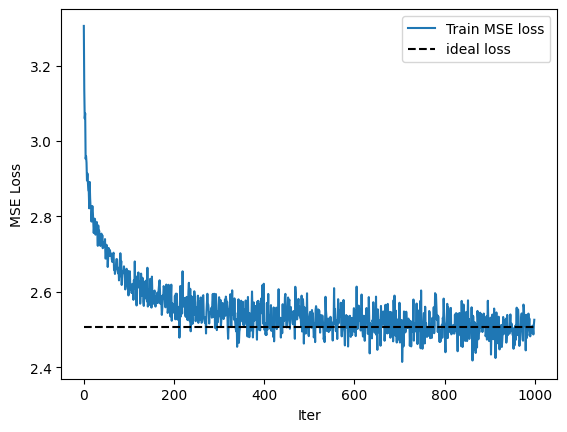

In [31]:
plt.plot(losses_CE, label="Train MSE loss")
plt.hlines(L_ideal,0,len(losses_CE),'k',ls='--',label='ideal loss')

plt.legend()
plt.xlabel("Iter")
plt.ylabel("MSE Loss")


**Can we visualize what the probability distribution looks like??**

In [32]:
# def get_prob(x, xx):
#     p0 = torch.distributions.Normal(loc=x + mu[0], scale=sigma[0]).log_prob(xx).exp()
#     p1 = torch.distributions.Normal(loc=x + mu[1], scale=sigma[1]).log_prob(xx).exp()
#     p2 = torch.distributions.Normal(loc=x + mu[2], scale=sigma[2]).log_prob(xx).exp()

#     p = 1 / 6 * p0 + 1 / 2 * p1 + 1 / 3 * p2
#     return p

def plot_mixture_bins(x=0.0):
    p = get_prob(x, xx)
    p_coarse = get_prob(x, y_mid)

    plt.figure()

    plt.hist(y_mid, edg, weights=p_coarse, label="discretized prob")

    with torch.no_grad():
        z_pred = m_class(torch.tensor(x).reshape(1,1))
        p_pred = nn.Softmax()(z_pred).squeeze()

    print("y_mid", sum(p_coarse))  # p_coarse.shape,
    print("y_pred", sum(p_pred[1:-1]))  # p_coarse.shape

    # toss under / overflow in first visible bin
    p_pred[1] += p_pred[0]
    p_pred[-2] += p_pred[-1]

    # This is a bit of a hack to get the visualization to work!
    # But the normalization of the probabilites isn't the point of the problem
    scale = torch.sum(p_coarse) / torch.sum(p_pred[1:-1])
    print('scale=',scale)

    plt.hist(
        y_mid,
        edg,
        weights=p_pred[1:-1] * scale,
        color="r",
        histtype="step",
        lw=3,
        label="predicted prob (classifier)",
    )

    plt.plot(xx, p, label="p", color="black", linewidth=3, alpha=0.5)
    plt.legend()
    plt.xlabel("y")
    plt.ylabel("p(y)")
    plt.title("Mixture of 3 Gaussians & discretization", loc="right")
    plt.show()


interact(plot_mixture_bins, x=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0));


interactive(children=(FloatSlider(value=0.0, description='x', max=3.0, min=-3.0), Output()), _dom_classes=('wi…

Yey!! we recovered a multimodal probability distribtuion!!

**How does this classifier model translate to MSE loss??**

In [33]:
def reco_y_from_int(y_int):
    """
    From an integer predicting the bin,
    return `y` the midpoint of the bin

    Input:
    - y_int: int tensor of shape (N,)
            Integers from [0,101), for under/overflow

    Output:
    - y_reco: float tensor (N,1)

    """

    # clip to be in the range to account for under / overflow
    y_clip = torch.clip(
        y_int, torch.tensor([1]), torch.tensor([nbins])
    )  # correct for under / overflow

    y_reco = y_mid[y_clip.squeeze() - 1]  # predict the bin centers

    return y_reco[:, None]  # reshape for shape expected by MSE


def reco_y_from_logits(z_pred):
    """
    From the logits which will predict the bin,
    return `y` the midpoint of the bin

    Input:
    - z_pred: float tensor of shape (N,102)

    Output:
    - y_reco: float tensor (N,1)

    """

    y_int = torch.argmax(z_pred, axis=1)
    y_reco = reco_y_from_int(y_int)

    return y_reco



In [34]:
"""
To do: I implemented some useful functions above for you,
just call the right one and calculate the MSE
"""

x, y = get_batch(1_000_000)

with torch.no_grad():
    z_pred = m_class(x)

y_reco = reco_y_from_logits(z_pred)

L_mse_ce = nn.MSELoss()(y_reco, y)  # just need to remember y_reco to be same shape as y
print("Final MSE loss", L_mse_ce)


Final MSE loss tensor(9.0737)


In [35]:
for i in range(10):
    print(y_reco[i],y[i])

tensor([0.4000]) tensor([-0.7928])
tensor([4.8000]) tensor([0.5033])
tensor([-4.8000]) tensor([-0.0410])
tensor([4.8000]) tensor([3.3744])
tensor([3.2000]) tensor([3.2644])
tensor([1.6000]) tensor([-1.5654])
tensor([-2.8000]) tensor([-2.7921])
tensor([4.8000]) tensor([5.7244])
tensor([3.6000]) tensor([0.0903])
tensor([-2.8000]) tensor([2.2497])


In [36]:
# !pip install corner

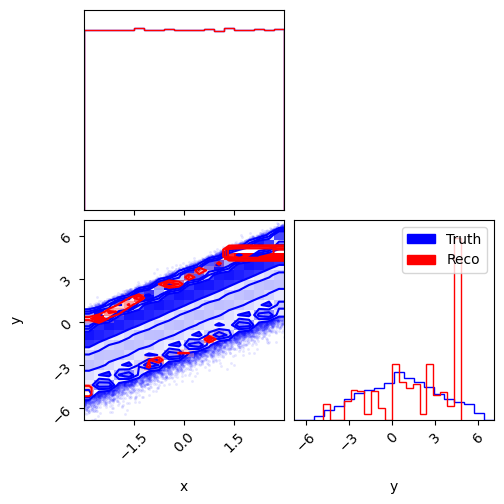

In [37]:
from corner import corner

# Stack your variables into 2D arrays (N_samples x N_dimensions)
data_true = np.column_stack([x, y])
data_reco = np.column_stack([x, y_reco])

labels = ["x", "y"]

# Plot truth first
fig = corner(
    data_true, labels=labels, color="blue", hist_kwargs={"density": True}, label="Truth"
)

# Overlay reco on the same figure
corner(
    data_reco,
    labels=labels,
    color="red",
    hist_kwargs={"density": True},
    fig=fig,
    label="Reco",
)

plt.legend(
    handles=[
        plt.matplotlib.patches.Patch(color="blue", label="Truth"),
        plt.matplotlib.patches.Patch(color="red", label="Reco"),
    ],
    loc="upper right",
)
plt.show()


The model seems to be over confident to predict the RHS of the distribution

In [38]:
# Quick sanity check that it's not an issue 
# w/ how expressive my model is!

# x, y = get_batch(int(10))
# y_int = torch.tensor(np.digitize(y.squeeze(), edg))

# y_reco = reco_y_from_int(y_int)

# L_CE_best = nn.MSELoss()(
#     y_reco, y
# )  # just need to remember y_reco to be same shape as y
# print("Best MSE loss", L_CE_best)

# The final MSE loss is in fact quite low!

## Part 3: Fit a FM model
<a id="cfm"></a>

Is there a model we can use to predict a multi-modal distribtuion, but still keep the continuous nature of the problem??

Yes!! Jed introduced conditional generative models last week to learn a parametrized distribtuion $p_\theta(y|x)$!

So... let's try to learn a conditional flow matching (FM) model for this task.

Note: when I train a FM for a new application, I like to use [standalone_flow_matching](https://github.com/facebookresearch/flow_matching/blob/main/examples/standalone_flow_matching.ipynb) as a starting point.

In [39]:
# Define the flow

from torch import Tensor
class Flow(nn.Module):
    def __init__(self, dim: int = 1, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 2, h),
            nn.ELU(),
            nn.Linear(h, h),
            nn.ELU(),
            nn.Linear(h, h),
            nn.ELU(),
            nn.Linear(h, dim),
        )

    def forward(self, t: Tensor, y_t: Tensor, x_t: Tensor) -> Tensor:
        '''
        y_t: the state vector that we want to evolve
        x_t: the conditional vector
        '''
        return self.net(torch.cat((t, y_t, x_t), -1))

    def step(self, y_t: Tensor, t_start: Tensor, t_end: Tensor, x_t: Tensor) -> Tensor:
        '''
        Integrate the ODE
        '''
        t_start = t_start.view(1, 1).expand(y_t.shape[0], 1)

        return y_t + (t_end - t_start) * self(
            t=t_start + (t_end - t_start) / 2,
            y_t=y_t + self(y_t=y_t, t=t_start, x_t=x_t) * (t_end - t_start) / 2,
            x_t=x_t
        )


In [40]:
# fit the flow

flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in range(10_000):
    # x_1 = Tensor(make_moons(256, noise=0.15)[0])

    x, y_1 = get_batch()

    y_0 = torch.randn_like(y_1)
    t = torch.rand(len(y_1), 1)

    y_t = (1 - t) * y_0 + t * y_1
    dy_t = y_1 - y_0

    optimizer.zero_grad()
    loss_fn(flow(t=t, y_t=y_t, x_t=x), dy_t).backward()
    optimizer.step()


And now draw samples

1) Remake the corner plot

In [41]:
x,y_true = get_batch(int(1e5)) # x: condition, y: state variable

n_steps = 10
time_steps = torch.linspace(0, 1.0, n_steps + 1)

y_pred = torch.randn_like(x) # init at y=0

with torch.no_grad():
    for i in range(n_steps):
        y_pred = flow.step(
            y_t=y_pred, t_start=time_steps[i], t_end=time_steps[i + 1], x_t=x
        )


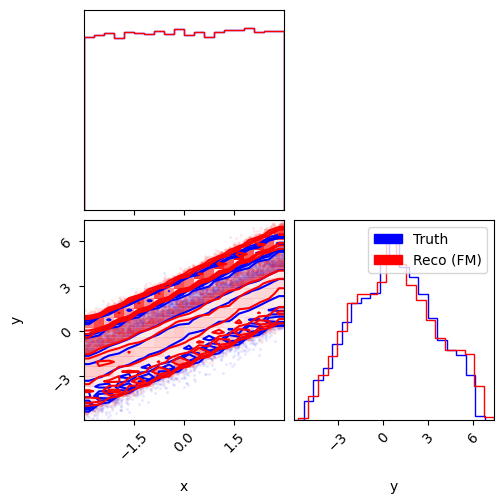

In [42]:
# Stack your variables into 2D arrays (N_samples x N_dimensions)
data_true = np.column_stack([x, y_true])
data_reco = np.column_stack([x, y_pred])

labels = ["x", "y"]

# Plot truth first
fig = corner(
    data_true, labels=labels, color="blue", hist_kwargs={"density": True}, label="Truth"
)

# Overlay reco on the same figure
corner(
    data_reco,
    labels=labels,
    color="red",
    hist_kwargs={"density": True},
    fig=fig,
    label="Reco",
)

plt.legend(
    handles=[
        plt.matplotlib.patches.Patch(color="blue", label="Truth"),
        plt.matplotlib.patches.Patch(color="red", label="Reco (FM)"),
    ],
    loc="upper right",
)
plt.show()


## What did we learn?

**How is this relevant for research?**

- Particle physics (the application I'm most familar with)

Inspired by recent advancements in LLMs and image generation...
there's a lot of interesting work along the lines of... _how can we build a large general purpose model for jet physics at the LHC_ that can then be used

Copying here an illustrative image of this idea from Michael Kagan (SLAC), from S. Klein's [IML talk](https://indico.cern.ch/event/1297159/contributions/5729217/attachments/2789213/4863674/MPM_IML_Talk.pdf).

<img src="../figures/Kagan-Jet-FM.png" >

Previous approaches needed to ``tokenize'' the particle 4-momenta (convert into one-hot integer representation) 
before developing the [Golling et. al. 2024a](https://arxiv.org/abs/2401.13537), [Birk et. al.]().

But... inspired exactly by the multi-modal target example you worked out above... recent work 
[Golling et. al. 2024b](https://arxiv.org/pdf/2409.12589) shows instead of tokenizing, 
can use a conditional generative model (e.g, Flow Matching) 
to learn such a multi-modal posterior, by-passing the need for a tokenization step.

Hopefully a funny concept integration exerciese!

(Also shout out to Lukas for sharing this idea with me last year to make a nice exercise for all of you!)
